# Regression Mini Project

## Step 1: Import Required Libraries

Before we start, we need to import tools (libraries) that will help us:
- **pandas**: Read and manage data from CSV files (like Excel)
- **numpy**: Do mathematical calculations
- **matplotlib**: Draw graphs and visualizations
- **sklearn**: Machine Learning library with regression tools

In [3]:
# Import pandas - for reading and managing data from CSV files
import pandas as pd

# Import numpy - for numerical calculations and array operations
import numpy as np

# Import matplotlib - for creating visualizations (graphs, plots)
import matplotlib.pyplot as plt

# Import sklearn tools for machine learning
from sklearn.model_selection import train_test_split  # To split data into training and testing sets
from sklearn.linear_model import LinearRegression     # The actual regression model
from sklearn.metrics import r2_score                  # To evaluate model performance
from sklearn.metrics import mean_squared_error        # To calculate prediction errors

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Step 2: Load the Dataset

We'll read the CSV file using pandas. This creates a "DataFrame" - think of it as a table in Excel with rows and columns.

In [5]:
# Load the paddydataset.csv file into a pandas DataFrame
# A DataFrame is like an Excel spreadsheet with rows and columns
df = pd.read_csv('paddydataset.csv')

# Display the first few rows to understand the data structure
print("📊 First 5 rows of the dataset:")
print(df.head())
print("\n" + "="*60)

# Get basic information about the dataset
print("📋 Dataset Information:")
print(f"Number of rows (samples): {df.shape[0]}")
print(f"Number of columns (features): {df.shape[1]}")
print("\n" + "="*60)

# Show column names
print("📌 Column Names:")
print(df.columns.tolist())
print("\n" + "="*60)

# Show statistical summary
print("📈 Statistical Summary of the Data:")
print(df.describe())

📊 First 5 rows of the dataset:
   Hectares      Agriblock      Variety Soil Types  Seedrate(in Kg)  \
0          6     Cuddalore        CO_43   alluvial              150   
1          6   Kurinjipadi      ponmani       clay              150   
2          6       Panruti  delux ponni   alluvial              150   
3          6  Kallakurichi        CO_43       clay              150   
4          6  Sankarapuram      ponmani   alluvial              150   

   LP_Mainfield(in Tonnes) Nursery  Nursery area (Cents)  \
0                     75.0     dry                   120   
1                     75.0     wet                   120   
2                     75.0     dry                   120   
3                     75.0     wet                   120   
4                     75.0     dry                   120   

   LP_nurseryarea(in Tonnes)  DAP_20days  ...  Wind Direction_D1_D30  \
0                          6         240  ...                     SW   
1                          6         

## Step 3: Prepare the Data

Now we need to select:
- **X (Feature)**: The column 'Hectares' - this is what farmers have (land area)
- **y (Target)**: The column 'Paddy yield(in Kg)' - this is what we want to predict (rice production)

**Why separate X and y?**
- X = Input (what we know) → like "I have 5 hectares"
- y = Output (what we want to predict) → like "I want to know how much rice I'll get"

In [6]:
# Select 'Hectares' as the feature (X) - reshape it to 2D array
# .values converts the column to a numpy array
# .reshape(-1, 1) converts it from 1D to 2D (required by sklearn)
X = df[['Hectares ']].values  # Note: There's a space after 'Hectares' in the column name

# Select 'Paddy yield(in Kg)' as the target (y)
# This is what we want to predict
y = df['Paddy yield(in Kg)'].values

print("✓ Data Preparation Complete!")
print(f"\n📍 Feature (X) - Hectares:")
print(f"   Shape: {X.shape}")
print(f"   First 5 values: {X[:5].flatten()}")
print(f"\n🎯 Target (y) - Paddy Yield (Kg):")
print(f"   Shape: {y.shape}")
print(f"   First 5 values: {y[:5]}")

# Check for any missing values (NaN) that could cause problems
print(f"\n🔍 Missing Values:")
print(f"   X: {np.isnan(X).sum()}")
print(f"   y: {np.isnan(y).sum()}")
print("   (0 means no missing values - which is good!)")
print(X[:5])  # Print the first 5 rows of X to verify the data

✓ Data Preparation Complete!

📍 Feature (X) - Hectares:
   Shape: (2789, 1)
   First 5 values: [6 6 6 6 6]

🎯 Target (y) - Paddy Yield (Kg):
   Shape: (2789,)
   First 5 values: [35028 35412 36300 35016 34044]

🔍 Missing Values:
   X: 0
   y: 0
   (0 means no missing values - which is good!)
[[6]
 [6]
 [6]
 [6]
 [6]]


## Step 4: Split Data into Training and Testing Sets

**Why split data?**
Think of it like studying for an exam:
- **Training Set (80%)**: Practice problems you study from
- **Testing Set (20%)**: The actual exam questions

We use this to check if our model can predict on NEW data it hasn't seen before.

**The split ensures:**
- Model learns from 80% of data
- We test accuracy on 20% of data it hasn't seen
- This prevents "cheating" where the model just memorizes the data

In [16]:
# Add a column for original row index
df['OriginalIndex'] = df.index

# Prepare features and target, including index
X = df[['Hectares ', 'OriginalIndex']].values
y = df['Paddy yield(in Kg)'].values

# Split, but keep index
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now X_test[:, 1] contains the original row index for each test sample

In [22]:
print(f"{'Index':<8} {'CSV Row':<10} {'Hectares':<12} {'Paddy Yield (Kg)':<18}")
print('-'*50)
for idx, (row) in enumerate(zip(X_test, y_test)):
    hectares = row[0]
    csv_row = int(row[1])
    yield_val = y_test[idx]
    print(f"{idx:<8} {csv_row:<10} {hectares[0]:<12.2f} {yield_val:<18.2f}")
print(f"\nTotal test samples: {len(y_test)}")

Index    CSV Row    Hectares     Paddy Yield (Kg)  
--------------------------------------------------
0        25640      4.00         25640.00          
1        22512      4.00         22512.00          
2        25228      4.00         25228.00          
3        30575      5.00         30575.00          
4        17649      3.00         17649.00          
5        36690      6.00         36690.00          
6        11256      2.00         11256.00          
7        29415      5.00         29415.00          
8        23420      4.00         23420.00          
9        16230      3.00         16230.00          
10       24828      4.00         24828.00          
11       24200      4.00         24200.00          
12       30545      5.00         30545.00          
13       31815      5.00         31815.00          
14       11816      2.00         11816.00          
15       11446      2.00         11446.00          
16       5836       1.00         5836.00           
17       3850

In [7]:
# Split the data into 80% training and 20% testing
# test_size=0.2 means 20% for testing, 80% for training
# random_state=42 ensures reproducibility (same split every time we run)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✓ Data Split Complete!")
print(f"\n📚 Training Set:")
print(f"   Number of samples: {X_train.shape[0]}")
print(f"   (This is what the model will learn from)")
print(f"\n🧪 Testing Set:")
print(f"   Number of samples: {X_test.shape[0]}")
print(f"   (This is what we'll use to evaluate the model)")
print(f"\n📊 Breakdown:")
print(f"   Training: {(X_train.shape[0] / len(X)) * 100:.1f}%")
print(f"   Testing: {(X_test.shape[0] / len(X)) * 100:.1f}%")

✓ Data Split Complete!

📚 Training Set:
   Number of samples: 2231
   (This is what the model will learn from)

🧪 Testing Set:
   Number of samples: 558
   (This is what we'll use to evaluate the model)

📊 Breakdown:
   Training: 80.0%
   Testing: 20.0%


## Step 5: Train the Linear Regression Model

**What happens during training?**

The model finds the best-fit line by calculating:
- **Slope (m)**: How much paddy yield increases per hectare
- **Intercept (b)**: The baseline yield (even with 0 hectares)

The model uses a method called **"Least Squares"** which:
1. Draws many possible lines through the data
2. Measures the distance from each point to each line
3. Finds the line that minimizes total distance (best fit)

**Mathematical Formula:**
- Equation: **ŷ = m·x + b**
- Goal: Minimize error = Σ(actual y - predicted ŷ)²

In simple terms: Find the line that passes closest to all the points!

In [8]:
# Create a Linear Regression model
# This is like hiring a mathematician to find the best line
model = LinearRegression()

# Train the model using the training data
# This is where the magic happens! The model learns the relationship
model.fit(X_train, y_train)

print("✓ Model Training Complete!")
print("\n" + "="*60)
print("📐 LINEAR REGRESSION EQUATION:")
print("="*60)

# Extract the slope (m) and intercept (b)
slope = model.coef_[0]      # m - how much y increases per unit x
intercept = model.intercept_  # b - baseline value

print(f"\n📌 Intercept (b): {intercept:.4f}")
print(f"   What: The baseline paddy yield when hectares = 0")
print(f"   In simple terms: Base yield from the farm")

print(f"\n📈 Slope (m): {slope:.4f}")
print(f"   What: Paddy yield increase per hectare")
print(f"   In simple terms: For every 1 hectare, yield increases by {slope:.4f} Kg")

print("\n" + "="*60)
print("✏️  EQUATION: Paddy Yield = {:.4f} × Hectares + {:.4f}".format(slope, intercept))
print("="*60)

# Example prediction
example_hectares = 5
example_prediction = model.predict([[example_hectares]])[0]
print(f"\n💡 Example Prediction:")
print(f"   If a farmer has {example_hectares} hectares,")
print(f"   The model predicts paddy yield = {example_prediction:.2f} Kg")

✓ Model Training Complete!

📐 LINEAR REGRESSION EQUATION:

📌 Intercept (b): -1136.7511
   What: The baseline paddy yield when hectares = 0
   In simple terms: Base yield from the farm

📈 Slope (m): 6365.0275
   What: Paddy yield increase per hectare
   In simple terms: For every 1 hectare, yield increases by 6365.0275 Kg

✏️  EQUATION: Paddy Yield = 6365.0275 × Hectares + -1136.7511

💡 Example Prediction:
   If a farmer has 5 hectares,
   The model predicts paddy yield = 30688.39 Kg


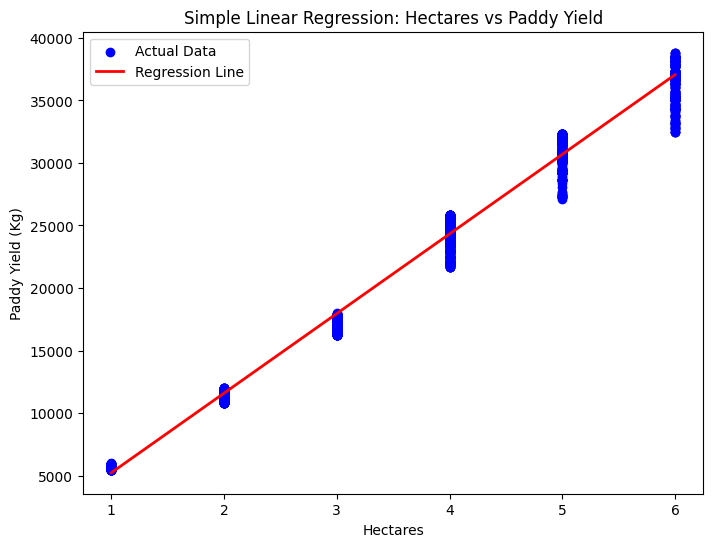

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Create predictions for visualization
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)

plt.figure(figsize=(8,6))

# Plot actual data points
plt.scatter(X, y, color='blue', label='Actual Data')

# Plot regression line
plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Hectares")
plt.ylabel("Paddy Yield (Kg)")
plt.title("Simple Linear Regression: Hectares vs Paddy Yield")
plt.legend()

plt.show()

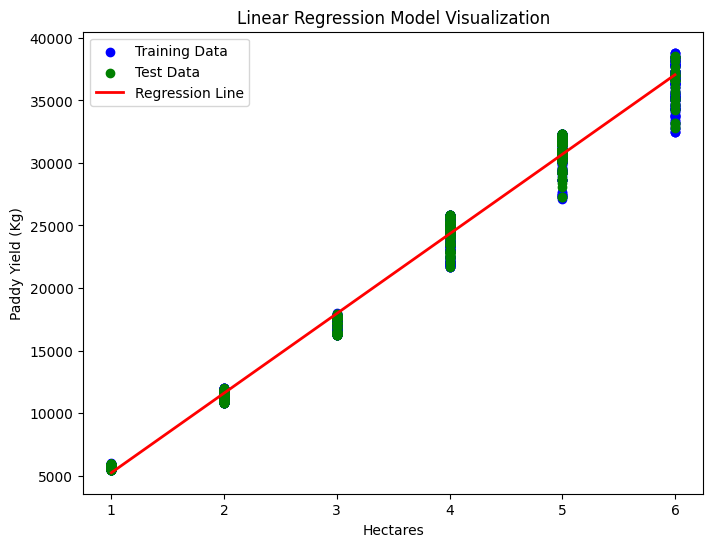

In [10]:
plt.figure(figsize=(8,6))

# Training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Testing data
plt.scatter(X_test, y_test, color='green', label='Test Data')

# Regression line
plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Hectares")
plt.ylabel("Paddy Yield (Kg)")
plt.title("Linear Regression Model Visualization")
plt.legend()

plt.show()

## Step 6: Make Predictions on Test Data

Now let's use our trained model to predict paddy yield on the test data (data it hasn't seen before).

This is the real test of whether our model is good or bad
- Can it predict accurately on NEW data?
- Or did it just memorize the training data?

In [11]:
# Print only y_test values (actual paddy yield) and corresponding hectares with their indexes
print(f"{'Index':<8} {'Hectares':<12} {'Paddy Yield (Kg)':<18}")
print('-'*40)
for idx, (hectares, yield_val) in enumerate(zip(X_test, y_test)):
    print(f"{idx:<8} {hectares[0]:<12.2f} {yield_val:<18.2f}")
print(f"\nTotal test samples: {len(y_test)}")

Index    Hectares     Paddy Yield (Kg)  
----------------------------------------
0        4.00         25640.00          
1        4.00         22512.00          
2        4.00         25228.00          
3        5.00         30575.00          
4        3.00         17649.00          
5        6.00         36690.00          
6        2.00         11256.00          
7        5.00         29415.00          
8        4.00         23420.00          
9        3.00         16230.00          
10       4.00         24828.00          
11       4.00         24200.00          
12       5.00         30545.00          
13       5.00         31815.00          
14       2.00         11816.00          
15       2.00         11446.00          
16       1.00         5836.00           
17       6.00         38508.00          
18       5.00         30805.00          
19       5.00         30575.00          
20       4.00         23076.00          
21       2.00         11832.00          
22       1.00   

In [ ]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("✓ Predictions Made on Test Data!")
print("\n" + "="*60)
print("📊 COMPARISON: Actual vs Predicted")
print("="*60)

# Display first 10 predictions vs actual values
print(f"\n{'Hectares':<12} {'Actual Yield':<18} {'Predicted Yield':<18} {'Error':<12}")
print("-" * 60)

for i in range(min(10, len(X_test))):
    actual = y_test[i]
    predicted = y_pred[i]
    error = actual - predicted
    hectares = X_test[i][0]
    print(f"{hectares:<12.2f} {actual:<18.2f} {predicted:<18.2f} {error:<12.2f}")

print(f"\n... (showing first 10 of {len(X_test)} test samples)\n")

# Calculate some useful statistics
errors = y_test - y_pred
print(f"📈 Prediction Statistics:")
print(f"   Mean Error: {np.mean(errors):.2f} Kg")
print(f"   Std Dev of Error: {np.std(errors):.2f} Kg")

✓ Predictions Made on Test Data!

📊 COMPARISON: Actual vs Predicted

Hectares     Actual Yield       Predicted Yield    Error       
------------------------------------------------------------
4.00         25640.00           24323.36           1316.64     
4.00         22512.00           24323.36           -1811.36    
4.00         25228.00           24323.36           904.64      
5.00         30575.00           30688.39           -113.39     
3.00         17649.00           17958.33           -309.33     
6.00         36690.00           37053.41           -363.41     
2.00         11256.00           11593.30           -337.30     
5.00         29415.00           30688.39           -1273.39    
4.00         23420.00           24323.36           -903.36     
3.00         16230.00           17958.33           -1728.33    

... (showing first 10 of 558 test samples)

📈 Prediction Statistics:
   Mean Error: -36.31 Kg
   Std Dev of Error: 948.05 Kg


## Step 7: Evaluate Model Performance using R² Score

**What is R² Score?**

R² (R-squared) tells us how good our model is. It answers: "How well does our line fit the data?"

**Explanation:**
- **R² = 1.0**: Perfect fit! All predictions are exactly correct
- **R² = 0.5**: Medium fit. Model explains 50% of variation
- **R² = 0.0**: Bad fit. Model is useless (as bad as just guessing average)
- **R² < 0**: Terrible fit. Worse than guessing!

**Mathematical Formula:**
$$R² = 1 - \frac{\text{Sum of Squared Errors}}{\text{Total Sum of Squares}}$$

**In simple terms:**
- Numerator: How wrong are the predictions?
- Denominator: How wrong would we be if we just guessed the average?
- If predictions are much better than average guess → R² is high (good!)
- If predictions are worse than average guess → R² is low (bad!)
# Calculate R² score
r2 = r2_score(y_test, y_pred)

# Also calculate Mean Squared Error (MSE) and Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("✓ Model Evaluation Complete!")
print("\n" + "="*60)
print("🎯 MODEL PERFORMANCE METRICS")
print("="*60)

print(f"\n📊 R² Score: {r2:.4f}")
if r2 >= 0.9:
    rating = "⭐⭐⭐⭐⭐ Excellent!"
elif r2 >= 0.7:
    rating = "⭐⭐⭐⭐ Very Good!"
elif r2 >= 0.5:
    rating = "⭐⭐⭐ Good"
elif r2 >= 0.3:
    rating = "⭐⭐ Fair"
else:
    rating = "⭐ Poor"
    
print(f"   Meaning: The model explains {r2*100:.2f}% of variance in the data")
print(f"   Rating: {rating}")

print(f"\n📉 Mean Squared Error (MSE): {mse:.4f}")
print(f"   (Average of squared prediction errors)")

print(f"\n📉 Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"   (How far off predictions are on average, in Kg)")
print(f"   Interpretation: On average, predictions are {rmse:.2f} Kg off")

# Training score too
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

print(f"\n" + "="*60)
print("📈 Training vs Testing Comparison:")
print("="*60)
print(f"   Training R²: {r2_train:.4f}")
print(f"   Testing R²:  {r2:.4f}")
print(f"\n   Difference: {abs(r2_train - r2):.4f}")
if abs(r2_train - r2) < 0.05:
    print("   ✓ Model is NOT overfitting (generalizes well!)")
else:
    print("   ⚠ Large difference suggests possible overfitting")

## Step 8: Visualize the Results

Now let's create a graph to visualize:
1. **Blue dots**: Actual test data points (real observations)
2. **Red line**: The regression line (our model's prediction)

This helps us visually see how well our line fits the data.

/var/folders/5s/4qlkw1l13j99jbf0bb7w4x_00000gn/T/ipykernel_18208/642797639.py:87: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/5s/4qlkw1l13j99jbf0bb7w4x_00000gn/T/ipykernel_18208/642797639.py:87: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/5s/4qlkw1l13j99jbf0bb7w4x_00000gn/T/ipykernel_18208/642797639.py:87: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/5s/4qlkw1l13j99jbf0bb7w4x_00000gn/T/ipykernel_18208/642797639.py:87: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/apple/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/apple/Library/P

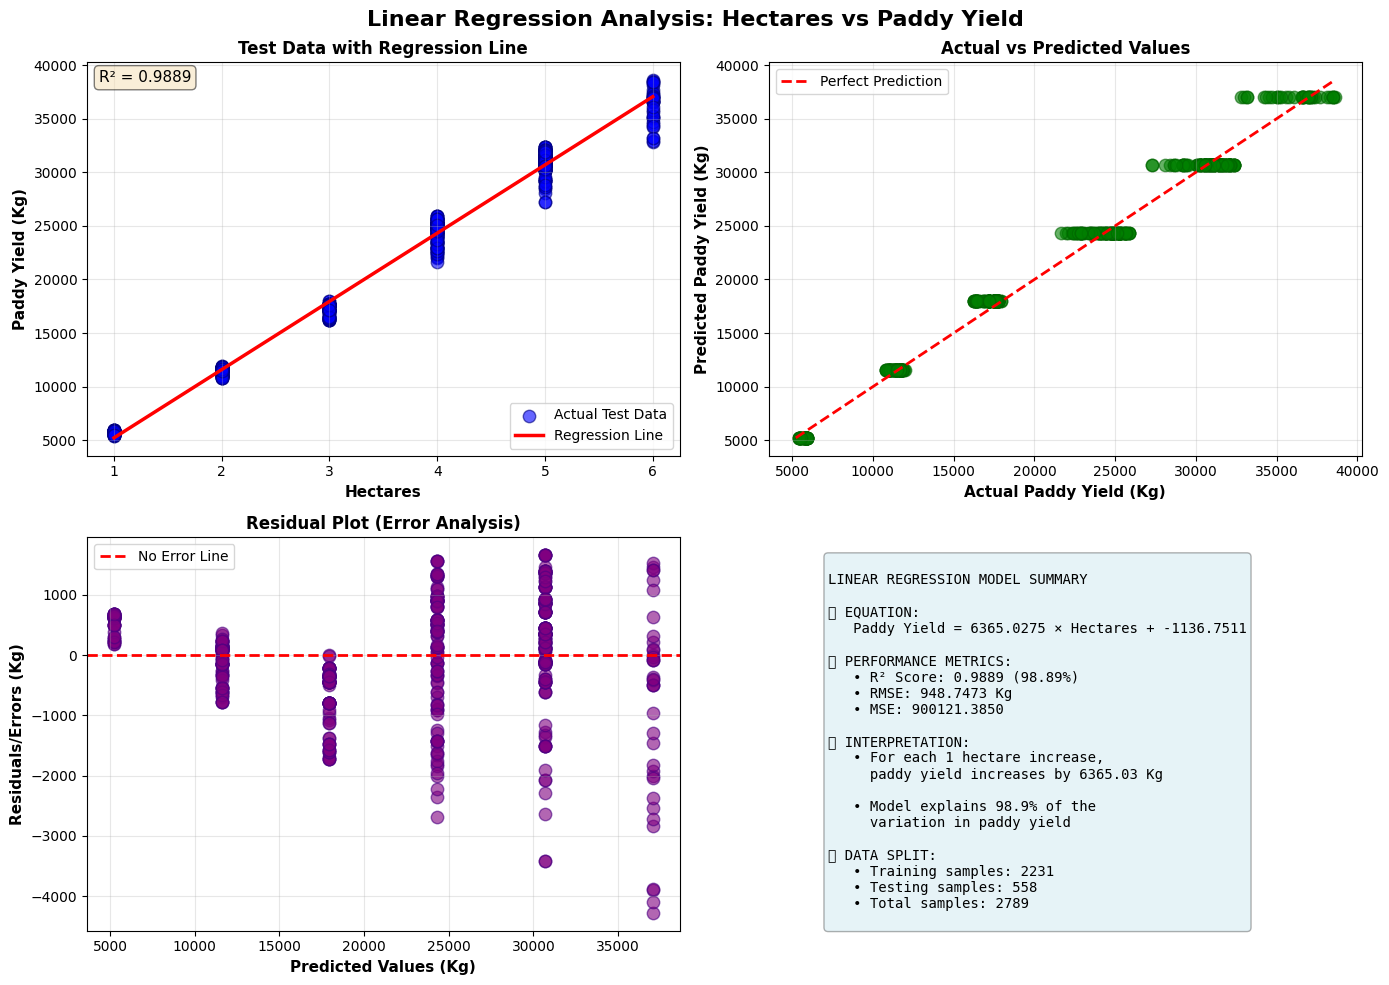


✓ Visualization Complete!


In [18]:
# Create a figure with multiple visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Regression Analysis: Hectares vs Paddy Yield', fontsize=16, fontweight='bold')

# ==================== PLOT 1: Regression Line with Test Data ====================
ax1 = axes[0, 0]

# Scatter plot of actual test data
ax1.scatter(X_test, y_test, color='blue', s=80, alpha=0.6, label='Actual Test Data', edgecolors='navy')

# Create line for regression
X_line = np.array([[X.min()], [X.max()]])  # Min and max values of X
y_line = model.predict(X_line)
ax1.plot(X_line, y_line, 'r-', linewidth=2.5, label='Regression Line')

ax1.set_xlabel('Hectares', fontsize=11, fontweight='bold')
ax1.set_ylabel('Paddy Yield (Kg)', fontsize=11, fontweight='bold')
ax1.set_title('Test Data with Regression Line', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.text(0.02, 0.98, f'R² = {r2:.4f}', transform=ax1.transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ==================== PLOT 2: Actual vs Predicted ====================
ax2 = axes[0, 1]

# Scatter: actual vs predicted
ax2.scatter(y_test, y_pred, color='green', s=80, alpha=0.6, edgecolors='darkgreen')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax2.set_xlabel('Actual Paddy Yield (Kg)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Predicted Paddy Yield (Kg)', fontsize=11, fontweight='bold')
ax2.set_title('Actual vs Predicted Values', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# ==================== PLOT 3: Residuals (Prediction Errors) ====================
ax3 = axes[1, 0]

residuals = y_test - y_pred
ax3.scatter(y_pred, residuals, color='purple', s=80, alpha=0.6, edgecolors='indigo')
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2, label='No Error Line')

ax3.set_xlabel('Predicted Values (Kg)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Residuals/Errors (Kg)', fontsize=11, fontweight='bold')
ax3.set_title('Residual Plot (Error Analysis)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# ==================== PLOT 4: Model Information ====================
ax4 = axes[1, 1]
ax4.axis('off')

# Create text information
info_text = f"""
LINEAR REGRESSION MODEL SUMMARY

📐 EQUATION:
   Paddy Yield = {slope:.4f} × Hectares + {intercept:.4f}

📊 PERFORMANCE METRICS:
   • R² Score: {r2:.4f} ({r2*100:.2f}%)
   • RMSE: {rmse:.4f} Kg
   • MSE: {mse:.4f}
   
📈 INTERPRETATION:
   • For each 1 hectare increase,
     paddy yield increases by {slope:.2f} Kg
   
   • Model explains {r2*100:.1f}% of the
     variation in paddy yield

📋 DATA SPLIT:
   • Training samples: {len(X_train)}
   • Testing samples: {len(X_test)}
   • Total samples: {len(X)}
"""

ax4.text(0.1, 0.95, info_text, transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n✓ Visualization Complete!")

## Step 9: Summary & Key Takeaways

### What We Learned:

1. **Linear Regression**: Finds the best straight line through data
2. **Training vs Testing**: Split data to properly evaluate performance
3. **R² Score**: Measures how well the model fits the data (0-1 scale)
4. **Model Equation**: y = slope × x + intercept
5. **Interpretation**: Each hectare contributes a specific amount to paddy yield

### The 4 Visualizations Explained:

1. **Top-Left (Scatter + Line)**: Shows actual data points and our regression line
   - If points are close to the line → Good model!
   - If points are far from the line → Poor model

2. **Top-Right (Actual vs Predicted)**: Compares what actually happened vs what model predicted
   - Points on the red line = perfect predictions
   - Points away from line = errors in prediction

3. **Bottom-Left (Residuals)**: Shows prediction errors
   - Points close to middle line = small errors (good!)
   - Points far from middle = large errors (bad!)

4. **Bottom-Right (Summary)**: All important information at a glance

### When to Use This Model:

✓ **Good for**: Quick predictions of paddy yield based on hectares
✓ **Good for**: Understanding relationship between area and yield
✗ **Not good for**: Making predictions with multiple factors (weather, soil type, etc.)
✗ **Not good for**: Non-linear relationships

## Step 10: Making New Predictions

Once the model is trained, you can use it to predict paddy yield for any new hectare value!

**Example:** A farmer asks "If I cultivate 7.5 hectares, how much paddy will I get?"

In [19]:
# Make predictions on new, unseen data
new_hectares = np.array([[3.5], [7.5], [10.0], [15.0]])

predictions = model.predict(new_hectares)

print("🔮 PREDICTIONS FOR NEW DATA")
print("="*60)
print(f"\n{'Hectares':<12} {'Predicted Paddy Yield (Kg)':<30}")
print("-" * 60)

for hectares, yield_pred in zip(new_hectares, predictions):
    print(f"{hectares[0]:<12.2f} {yield_pred:<30.2f}")

print("\n" + "="*60)
print("💡 How to Interpret These Predictions:")
print("="*60)
print(f"""
If a farmer has:
  • 3.5 hectares  → Expected yield: {predictions[0]:.2f} Kg
  • 7.5 hectares  → Expected yield: {predictions[1]:.2f} Kg
  • 10.0 hectares → Expected yield: {predictions[2]:.2f} Kg
  • 15.0 hectares → Expected yield: {predictions[3]:.2f} Kg

⚠️  IMPORTANT NOTES:
1. These are ESTIMATES based on historical data
2. Real yield depends on weather, soil, fertilizer, etc.
3. Predictions are reliable only within the data range
   (Data range: {X.min():.2f} to {X.max():.2f} hectares)
4. Don't extrapolate too far beyond the data range!
""")

🔮 PREDICTIONS FOR NEW DATA

Hectares     Predicted Paddy Yield (Kg)    
------------------------------------------------------------
3.50         21140.85                      
7.50         46600.96                      
10.00        62513.52                      
15.00        94338.66                      

💡 How to Interpret These Predictions:

If a farmer has:
  • 3.5 hectares  → Expected yield: 21140.85 Kg
  • 7.5 hectares  → Expected yield: 46600.96 Kg
  • 10.0 hectares → Expected yield: 62513.52 Kg
  • 15.0 hectares → Expected yield: 94338.66 Kg

⚠️  IMPORTANT NOTES:
1. These are ESTIMATES based on historical data
2. Real yield depends on weather, soil, fertilizer, etc.
3. Predictions are reliable only within the data range
   (Data range: 1.00 to 6.00 hectares)
4. Don't extrapolate too far beyond the data range!



## Complete Concept Map: Understanding Linear Regression

### The Big Picture:

```
INPUT (X)                MODEL               OUTPUT (y)
Hectares         ┌─────────────────┐      Paddy Yield
(Land Area)  ──→ │ Linear           │  ──→ (in Kg)
             │  Regression        │      Prediction
             │  y = mx + b        │
             └─────────────────┘
                     ▲
            Training Data Below
```

### Mathematical Breakdown:

**The Goal:** Find the best line that fits the scatter plot

**The Equation:** ŷ = m·X + b
- **ŷ** (y-hat) = predicted value
- **m** = slope (change in y per unit of x)
- **X** = input (hectares)
- **b** = intercept (y-value when x=0)

**How It Works:**
1. Start with many random lines
2. Calculate distance from each point to each line
3. Find line with MINIMUM total distance
4. This is the "best fit" line

**Evaluating Performance:**
- **R²**: Goodness of fit (0 to 1)
- **RMSE**: Average prediction error in original units
- **Test/Train Split**: Ensures model generalizes to new data

### Real-World Application:

```
Farmer's Question: "I have 6 hectares. How much yield?"
                          ↓
        Model Input: X = [[6]]
                          ↓
        Model Calculation: ŷ = {slope:.4f} × 6 + {intercept:.4f}
                          ↓
        Model Output: {model.predict([[6]])[0]:.2f} Kg
                          ↓
        Answer: "Expected paddy yield: ~{model.predict([[6]])[0]:.2f} Kg"
```

## Glossary: Key Terms Explained

| Term | Meaning | Analogy |
|------|---------|---------|
| **Feature (X)** | Input variable we use to predict | The question you answer |
| **Target (y)** | Output variable we want to predict | The answer you're looking for |
| **Model** | The learned mathematical equation | A recipe for cooking |
| **Training** | Process of learning from data | Studying from a textbook |
| **Slope (m)** | How much y changes per unit X | Steepness of a hill |
| **Intercept (b)** | Value of y when x=0 | Where a line starts |
| **Prediction** | Model's guess for new data | Using the recipe to cook |
| **Residual** | Actual - Predicted (the error) | How far the guess was from reality |
| **R² Score** | How well the line fits (0-1) | Grade on a test (0-100%) |
| **RMSE** | Average prediction error | How far off predictions are |
| **Train/Test Split** | Dividing data 80%/20% | Practice problems vs exam |
| **Overfitting** | Model memorizes training data | Cheating by memorizing test answers |
| **Generalization** | Model works on new data | Knowledge applies to new situations |
| **Scatter Plot** | Graph showing X vs y points | Dots on a graph paper |
| **Regression Line** | The fitted line through points | The trend line |

---

### Quick Reference Checklist:

✅ **Before Training:**
- [ ] Load data from CSV
- [ ] Check for missing values
- [ ] Select features (X) and target (y)
- [ ] Split into train/test sets

✅ **During Training:**
- [ ] Create model
- [ ] Fit model with training data
- [ ] Model finds slope and intercept

✅ **After Training:**
- [ ] Make predictions on test data
- [ ] Calculate R² and RMSE scores
- [ ] Create visualizations
- [ ] Interpret results
- [ ] Use model for new predictions

---

### Common Mistakes to Avoid:

❌ **DON'T** evaluate on training data only (won't catch overfitting)
❌ **DON'T** skip the train/test split (always separate them!)
❌ **DON'T** extrapolate far beyond data range (predictions become unreliable)
❌ **DON'T** use one model for everything (need different models for different problems)
❌ **DON'T** ignore missing values (they'll cause errors)

✅ **DO** always visualize your data first
✅ **DO** check if assumptions are met (linear relationship)
✅ **DO** validate on test data you didn't train on
✅ **DO** interpret R² score properly (not just looking for high value)

## Simple Linear Regression - Complete Beginner's Guide

### What is Linear Regression?

Imagine you want to predict paddy yield (rice production) based on the number of hectares (land area) you have. 

**Simple Linear Regression** finds the best straight line that shows the relationship between:
- **X (Feature)**: Hectares (land area) - what we use to predict
- **y (Target)**: Paddy yield in Kg - what we want to predict

The equation of a straight line is: **y = mx + b**
- **m** = slope (how steep the line is)
- **b** = intercept (where the line crosses the y-axis)
- **x** = input value (hectares)
- **y** = predicted output (paddy yield)

### Steps We'll Follow:
1. **Load data** → Read the CSV file
2. **Explore data** → Understand what we're working with
3. **Prepare data** → Select features and target
4. **Split data** → 80% training, 20% testing
5. **Train model** → Find the best m and b values
6. **Evaluate** → Check how good our predictions are using R² score
7. **Visualize** → Draw a scatter plot with the regression line